# CÁC BÀI LAB LÀM SẠCH DỮ LIỆU - WEEK 4

## Mục lục
1. **Lab 4: Data Wrangling và Làm sạch dữ liệu**
2. **Khai thác và xử lý dữ liệu - Trực quan hóa dữ liệu**
3. **Mô tả dữ liệu**
4. **Khai thác sự phân phối dữ liệu**
5. **Phân tích tương quan**
6. **Thao tác dữ liệu nâng cao**
7. **Kết nối SQL Server**

---


## 1. Lab 4: Data Wrangling và Làm sạch dữ liệu

### 1.1. Import các thư viện cần thiết


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Đã import thành công các thư viện cần thiết!")
print("✅ Sẵn sàng sử dụng np.count_nonzero")


Đã import thành công các thư viện cần thiết!
✅ Sẵn sàng sử dụng np.count_nonzero


### 1.2. Đọc dữ liệu


In [41]:
# 1.1. Đọc dữ liệu từ file thực tế
print("Đang đọc dữ liệu từ file 'orginal_sales_data_edit.csv'...")
try:
    df = pd.read_csv('orginal_sales_data_edit.csv', encoding='utf-8', header=0, delimiter=',')
    print(f"✅ Đã đọc thành công dữ liệu với {len(df)} dòng")
    print(f"📊 Kích thước dữ liệu: {df.shape}")
    print(f"📋 Số cột: {len(df.columns)}")
    
    print("\n📝 Thông tin cơ bản về dữ liệu:")
    print(df.info())
    
    print("\n🔍 Kiểm tra dữ liệu thiếu:")
    missing_data = df.isnull().sum()
    print(missing_data[missing_data > 0])
    
except FileNotFoundError:
    print("❌ Không tìm thấy file 'orginal_sales_data_edit.csv'")
    print("Tạo dữ liệu mẫu để demo...")
    # Tạo dữ liệu mẫu
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'ORDERNUMBER': range(10100, 10100 + n_samples),
        'ORDERDATE': pd.date_range('2020-01-01', periods=n_samples, freq='D'),
        'QUANTITYORDERED': np.random.randint(1, 100, n_samples),
        'PRICEEACH': np.random.uniform(20, 200, n_samples),
        'SALES': np.random.uniform(100, 10000, n_samples),
        'STATUS': np.random.choice(['Shipped', 'Cancelled', 'In Process'], n_samples),
        'DEALSIZE': np.random.choice(['Small', 'Medium', 'Large'], n_samples),
        'YEAR_ID': np.random.choice([2020, 2021, 2022], n_samples),
        'MONTH_ID': np.random.randint(1, 13, n_samples),
        'QTR_ID': np.random.randint(1, 5, n_samples),
        'ADDRESSLINE2': np.random.choice([None, 'Apt 1', 'Suite 2', 'Floor 3'], n_samples),
        'STATE': np.random.choice([None, 'CA', 'NY', 'TX', 'FL'], n_samples),
        'TERRITORY': np.random.choice([None, 'NA', 'EMEA', 'APAC'], n_samples),
        'POSTALCODE': np.random.choice([None, 12345, 67890, 11111], n_samples),
        'PAYMENTFULLNAME': [f"John {i} Smith" for i in range(n_samples)],
        'MSRP': np.random.uniform(50, 300, n_samples)
    })
    
    print(f"Đã tạo dữ liệu mẫu với {len(df)} dòng")

# Hiển thị 5 dòng đầu tiên
print("\n📋 5 dòng đầu tiên:")
df.head()


Đang đọc dữ liệu từ file 'orginal_sales_data_edit.csv'...
✅ Đã đọc thành công dữ liệu với 2823 dòng
📊 Kích thước dữ liệu: (2823, 28)
📋 Số cột: 28

📝 Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CATEG

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie


In [42]:
# Hiển thị thông tin chi tiết về dữ liệu thực tế
print("📊 THÔNG TIN CHI TIẾT VỀ DỮ LIỆU:")
print("=" * 50)

# Thống kê cơ bản
print(f"📈 Thống kê cơ bản:")
print(f"   - Tổng số dòng: {len(df):,}")
print(f"   - Tổng số cột: {len(df.columns)}")
print(f"   - Kích thước bộ nhớ: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Thống kê theo năm
print(f"\n📅 Phân bố theo năm:")
year_counts = df['YEAR_ID'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"   - Năm {year}: {count:,} đơn hàng")

# Thống kê theo trạng thái
print(f"\n📦 Phân bố theo trạng thái:")
status_counts = df['STATUS'].value_counts()
for status, count in status_counts.items():
    print(f"   - {status}: {count:,} đơn hàng")

# Thống kê theo dealsize
print(f"\n💰 Phân bố theo dealsize:")
dealsize_counts = df['DEALSIZE'].value_counts()
for size, count in dealsize_counts.items():
    print(f"   - {size}: {count:,} đơn hàng")

# Thống kê doanh số
print(f"\n💵 Thống kê doanh số:")
print(f"   - Tổng doanh số: ${df['SALES'].sum():,.2f}")
print(f"   - Doanh số trung bình: ${df['SALES'].mean():.2f}")
print(f"   - Doanh số cao nhất: ${df['SALES'].max():.2f}")
print(f"   - Doanh số thấp nhất: ${df['SALES'].min():.2f}")

# Hiển thị một số dòng mẫu
print(f"\n📋 Mẫu dữ liệu (5 dòng đầu):")
display_cols = ['ORDERNUMBER', 'ORDERDATE', 'QUANTITYORDERED', 'PRICEEACH', 'SALES', 'STATUS', 'DEALSIZE']
print(df[display_cols].head())


📊 THÔNG TIN CHI TIẾT VỀ DỮ LIỆU:
📈 Thống kê cơ bản:
   - Tổng số dòng: 2,823
   - Tổng số cột: 28
   - Kích thước bộ nhớ: 3.41 MB

📅 Phân bố theo năm:
   - Năm 2003: 1,000 đơn hàng
   - Năm 2004: 1,345 đơn hàng
   - Năm 2005: 478 đơn hàng

📦 Phân bố theo trạng thái:
   - Shipped: 2,617 đơn hàng
   - Cancelled: 60 đơn hàng
   - Resolved: 47 đơn hàng
   - On Hold: 44 đơn hàng
   - In Process: 41 đơn hàng
   - Disputed: 14 đơn hàng

💰 Phân bố theo dealsize:
   - Medium: 1,384 đơn hàng
   - Small: 1,282 đơn hàng
   - Large: 157 đơn hàng

💵 Thống kê doanh số:
   - Tổng doanh số: $10,032,628.85
   - Doanh số trung bình: $3553.89
   - Doanh số cao nhất: $14082.80
   - Doanh số thấp nhất: $482.13

📋 Mẫu dữ liệu (5 dòng đầu):
   ORDERNUMBER   ORDERDATE  QUANTITYORDERED  PRICEEACH    SALES   STATUS  \
0        10107   2/24/2003               30      95.70  2871.00  Shipped   
1        10121    5/7/2003               34      81.35  2765.90  Shipped   
2        10134    7/1/2003               41  

### 1.3. Loại bỏ dữ liệu trùng lặp


In [43]:
# 1.2. Loại bỏ dòng dữ liệu rỗng
print("Dữ liệu trước khi loại bỏ dòng rỗng:")
print(f"Số dòng: {len(df)}")

df.dropna(how='all', inplace=True)
print(f"\nDữ liệu sau khi loại bỏ dòng rỗng:")
print(f"Số dòng: {len(df)}")

# 1.3. Loại bỏ dữ liệu trùng lặp
print(f"\nDữ liệu trước khi loại bỏ trùng lặp:")
print(f"Số dòng: {len(df)}")

# Loại bỏ dữ liệu trùng lặp dựa trên ORDERNUMBER và ORDERDATE
df.drop_duplicates(subset=['ORDERNUMBER', 'ORDERDATE'], inplace=True)
print(f"\nDữ liệu sau khi loại bỏ trùng lặp theo ORDERNUMBER và ORDERDATE:")
print(f"Số dòng: {len(df)}")

# Kiểm tra dữ liệu trùng lặp hoàn toàn
df.drop_duplicates(inplace=True)
print(f"\nDữ liệu sau khi loại bỏ trùng lặp hoàn toàn:")
print(f"Số dòng: {len(df)}")

df.head()


Dữ liệu trước khi loại bỏ dòng rỗng:
Số dòng: 2823

Dữ liệu sau khi loại bỏ dòng rỗng:
Số dòng: 2823

Dữ liệu trước khi loại bỏ trùng lặp:
Số dòng: 2823

Dữ liệu sau khi loại bỏ trùng lặp theo ORDERNUMBER và ORDERDATE:
Số dòng: 307

Dữ liệu sau khi loại bỏ trùng lặp hoàn toàn:
Số dòng: 307


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,PAYMENTFULLNAME
0,10107,30,95.70,2,2871.00,2/24/2003,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,Yu Kwai
1,10121,34,81.35,5,2765.90,5/7/2003,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,Henriot Paul
2,10134,41,94.74,2,3884.34,7/1/2003,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,DaCunha Daniel
3,10145,45,83.26,6,3746.70,8/25/2003,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,Young Julie
4,10159,49,100.00,14,5205.27,10/10/2003,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,Brown Julie


### 1.4. Kiểm tra dữ liệu thiếu bằng biểu đồ


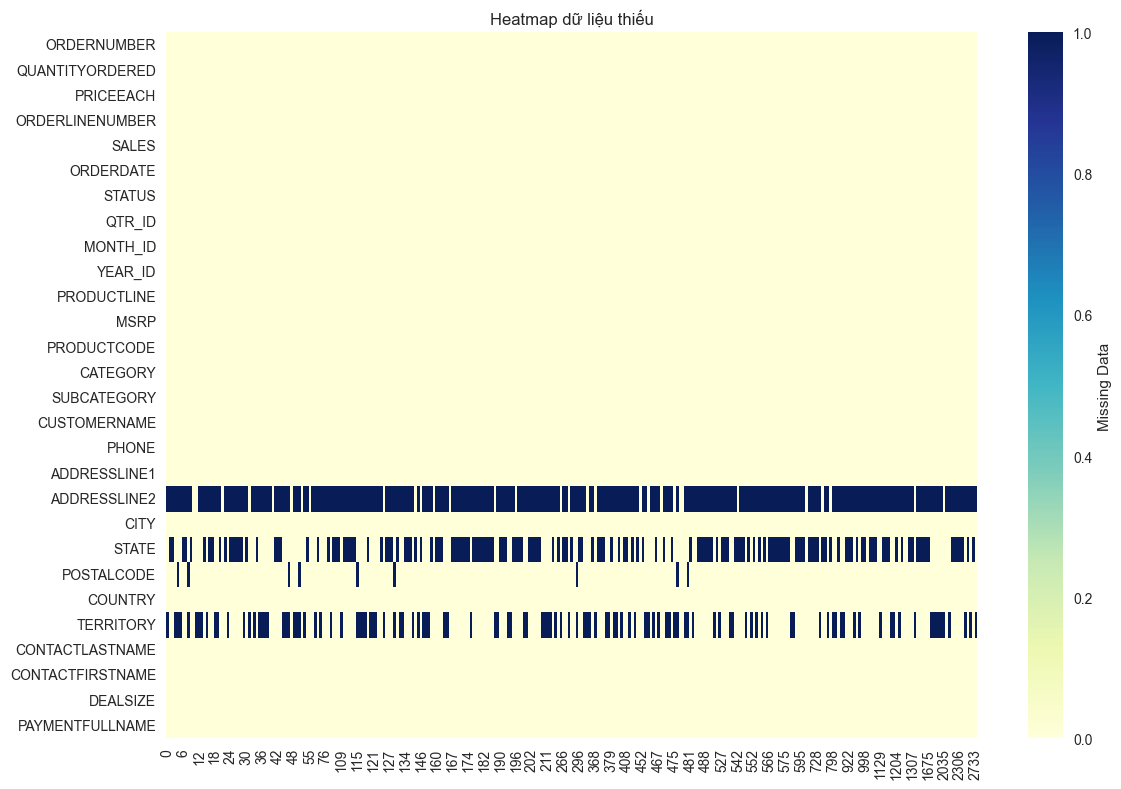

<Figure size 1000x600 with 0 Axes>

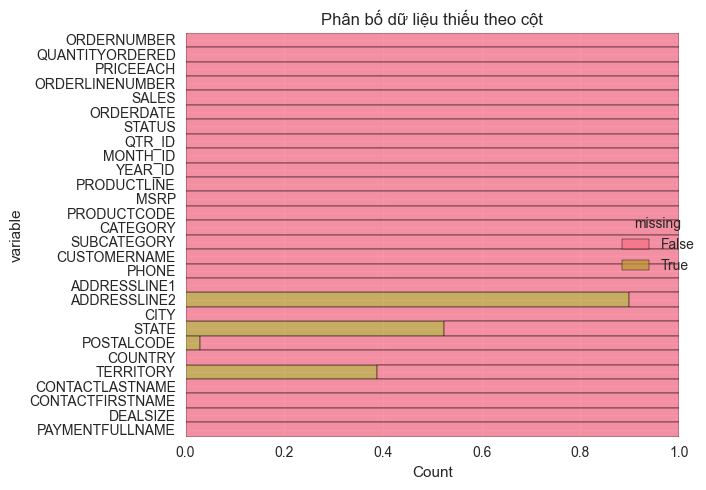

Thống kê dữ liệu thiếu:
              Số lượng thiếu  Tỷ lệ thiếu (%)
ADDRESSLINE2             276        89.902280
STATE                    161        52.442997
POSTALCODE                 9         2.931596
TERRITORY                119        38.762215


In [44]:
# 1.4. Kiểm tra dữ liệu thiếu bằng biểu đồ

# Cách 1: Trực quan dữ liệu thiếu với Seaborn HeatMap
plt.figure(figsize=(12, 8))
sns.heatmap(df.isna().transpose(), cmap="YlGnBu", cbar_kws={'label': 'Missing Data'})
plt.title('Heatmap dữ liệu thiếu')
plt.tight_layout()
plt.show()

# Cách 2: Trực quan dữ liệu thiếu với Seaborn Displot
plt.figure(figsize=(10, 6))
missing_data = df.isna().melt(value_name="missing")
sns.displot(data=missing_data, y="variable", hue="missing", multiple="fill", aspect=1.25)
plt.title('Phân bố dữ liệu thiếu theo cột')
plt.tight_layout()
plt.show()

# Thống kê dữ liệu thiếu
print("Thống kê dữ liệu thiếu:")
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_stats,
    'Tỷ lệ thiếu (%)': missing_percent
})
print(missing_df[missing_df['Số lượng thiếu'] > 0])


### 1.5. Xử lý dữ liệu thiếu


In [45]:
# 1.4.1. Điền thiếu dữ liệu với dữ liệu định tính
# 1.4.1.1. Với dữ liệu biểu diễn dạng chuỗi thì thay bằng Unknown
# 1.4.1.2. Với dữ liệu biểu diễn dạng số thì thay bằng 0

# Điền dữ liệu thiếu cho các cột định tính
df['ADDRESSLINE2'].fillna('Unknown', inplace=True)
df['STATE'].fillna('Unknown', inplace=True)
df['TERRITORY'].fillna('Unknown', inplace=True)

# Điền dữ liệu thiếu cho các cột định lượng
df['POSTALCODE'].fillna(0, inplace=True)

print("Xem lại thông tin sau khi điền dữ liệu thiếu:")
print(df[['ADDRESSLINE2', 'STATE', 'TERRITORY', 'POSTALCODE']].head(10))

# Kiểm tra lại dữ liệu thiếu
print("\nDữ liệu thiếu sau khi xử lý:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])


Xem lại thông tin sau khi điền dữ liệu thiếu:
  ADDRESSLINE2    STATE TERRITORY POSTALCODE
0      Unknown       NY   Unknown      10022
1      Unknown  Unknown      EMEA      51100
2      Unknown  Unknown      EMEA      75508
3      Unknown       CA   Unknown      90003
4      Unknown       CA   Unknown          0
5      Unknown       CA   Unknown      94217
6      Unknown  Unknown      EMEA      59000
7      Unknown  Unknown      EMEA     N 5804
8      Unknown       CA   Unknown          0
9      Unknown  Unknown      EMEA      75016

Dữ liệu thiếu sau khi xử lý:
Series([], dtype: int64)


### 1.6. Tách cột và tạo cột mới


In [46]:
# 1.5. Tách 1 cột thành 2 cột. Sau đó xóa cột bị tách
# Tách cột PAYMENTFULLNAME thành PAYMENTLASTNAME và PAYMENTFIRSTNAME
# Xử lý trường hợp tên có nhiều hơn 2 phần và giá trị null

print("🔍 Kiểm tra dữ liệu PAYMENTFULLNAME:")
print(f"Số dòng có giá trị null: {df['PAYMENTFULLNAME'].isnull().sum()}")
print(f"Mẫu dữ liệu:")
print(df['PAYMENTFULLNAME'].head(10))

# Kiểm tra các trường hợp đặc biệt
print(f"\n📊 Thống kê về tên:")
print(f"Số từ trung bình trong tên: {df['PAYMENTFULLNAME'].str.split().str.len().mean():.2f}")
print(f"Số từ tối đa trong tên: {df['PAYMENTFULLNAME'].str.split().str.len().max()}")

# Xử lý giá trị null trước
df['PAYMENTFULLNAME'] = df['PAYMENTFULLNAME'].fillna('Unknown Unknown')

# Tách cột với xử lý trường hợp có nhiều hơn 2 phần
# Chỉ lấy phần đầu tiên làm tên và phần còn lại làm họ
name_parts = df['PAYMENTFULLNAME'].str.split(' ', n=1, expand=True)
df['PAYMENTFIRSTNAME'] = name_parts[0]
df['PAYMENTLASTNAME'] = name_parts[1].fillna('Unknown')

# Xóa cột gốc
df = df.drop('PAYMENTFULLNAME', axis=1)

print("\n✅ Kết quả sau khi tách cột:")
print(df[['PAYMENTFIRSTNAME', 'PAYMENTLASTNAME']].head())

# 1.6. Lưu dữ liệu thành file mới
df.to_csv('processed_sales_data.csv', sep=',', encoding='utf-8', index=False)
print(f"\n💾 Đã lưu dữ liệu đã xử lý vào file 'processed_sales_data.csv'")
print(f"📊 Số dòng cuối cùng: {len(df)}")
print(f"📋 Số cột cuối cùng: {len(df.columns)}")


🔍 Kiểm tra dữ liệu PAYMENTFULLNAME:
Số dòng có giá trị null: 0
Mẫu dữ liệu:
0              Yu Kwai
1         Henriot Paul
2       DaCunha Daniel
3          Young Julie
4          Brown Julie
5          Hirano Juri
6        Rance Martine
7        Oeztan Veysel
8         Murphy Julie
9    Perrier Dominique
Name: PAYMENTFULLNAME, dtype: object

📊 Thống kê về tên:
Số từ trung bình trong tên: 2.00
Số từ tối đa trong tên: 2

✅ Kết quả sau khi tách cột:
  PAYMENTFIRSTNAME PAYMENTLASTNAME
0               Yu            Kwai
1          Henriot            Paul
2          DaCunha          Daniel
3            Young           Julie
4            Brown           Julie

💾 Đã lưu dữ liệu đã xử lý vào file 'processed_sales_data.csv'
📊 Số dòng cuối cùng: 307
📋 Số cột cuối cùng: 29


## 2. Khai thác và xử lý dữ liệu - Trực quan hóa dữ liệu

### 2.1. Biểu đồ cột (Bar Plot)


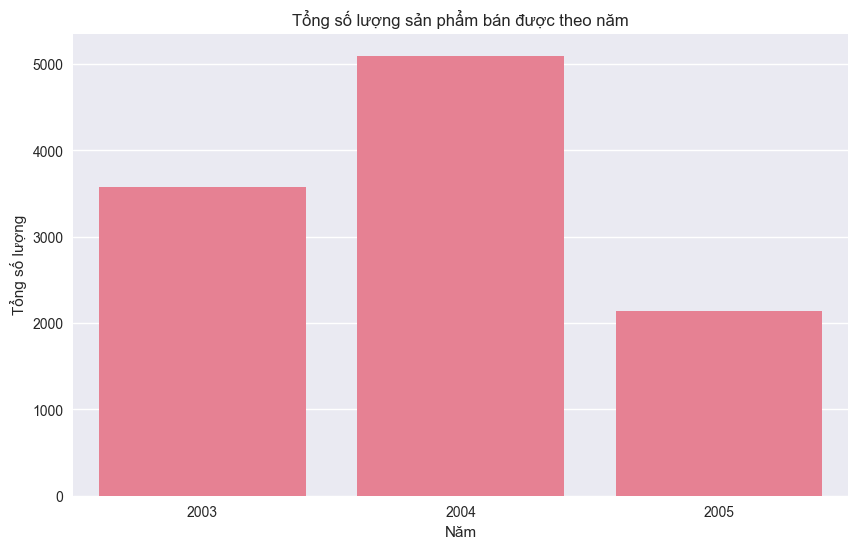

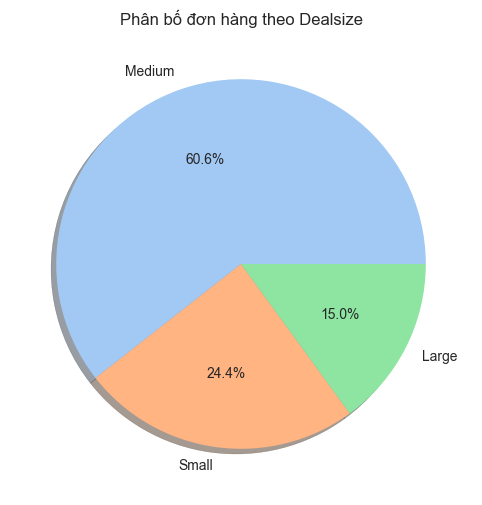

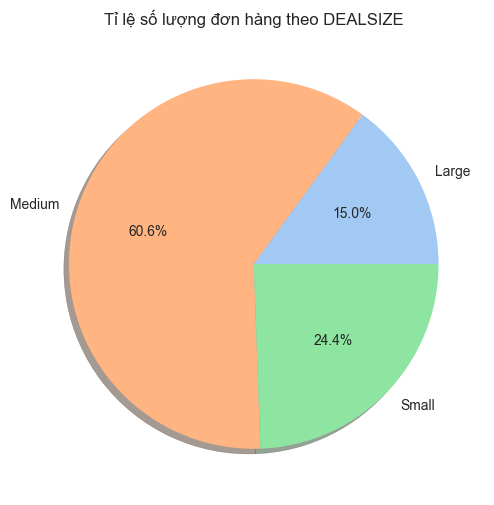

In [47]:
# 2.1.1. Cho biết tổng số lượng sản phẩm bán được của mỗi năm
plt.figure(figsize=(10, 6))
sns.barplot(x='YEAR_ID', y='QUANTITYORDERED', data=df, errorbar=None, estimator=sum)
plt.title('Tổng số lượng sản phẩm bán được theo năm')
plt.xlabel('Năm')
plt.ylabel('Tổng số lượng')
plt.show()

# 2.1.2. Có bao nhiêu đơn hàng theo Dealsize
plt.figure(figsize=(10, 6))
labels = df['DEALSIZE'].value_counts().index
values = df['DEALSIZE'].value_counts().values
colors = sns.color_palette('pastel')

plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.title('Phân bố đơn hàng theo Dealsize')
plt.show()

# 2.1.3. Cho biết tỉ lệ giá trị SALES theo DEALSIZE
plt.figure(figsize=(10, 6))
gb = df.groupby(['DEALSIZE'])['ORDERNUMBER'].agg(['count'])
data = list(gb['count'])
labels = gb.index
colors = sns.color_palette('pastel')

plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.title('Tỉ lệ số lượng đơn hàng theo DEALSIZE')
plt.show()


### 2.2. Biểu đồ đường (Line Plot)


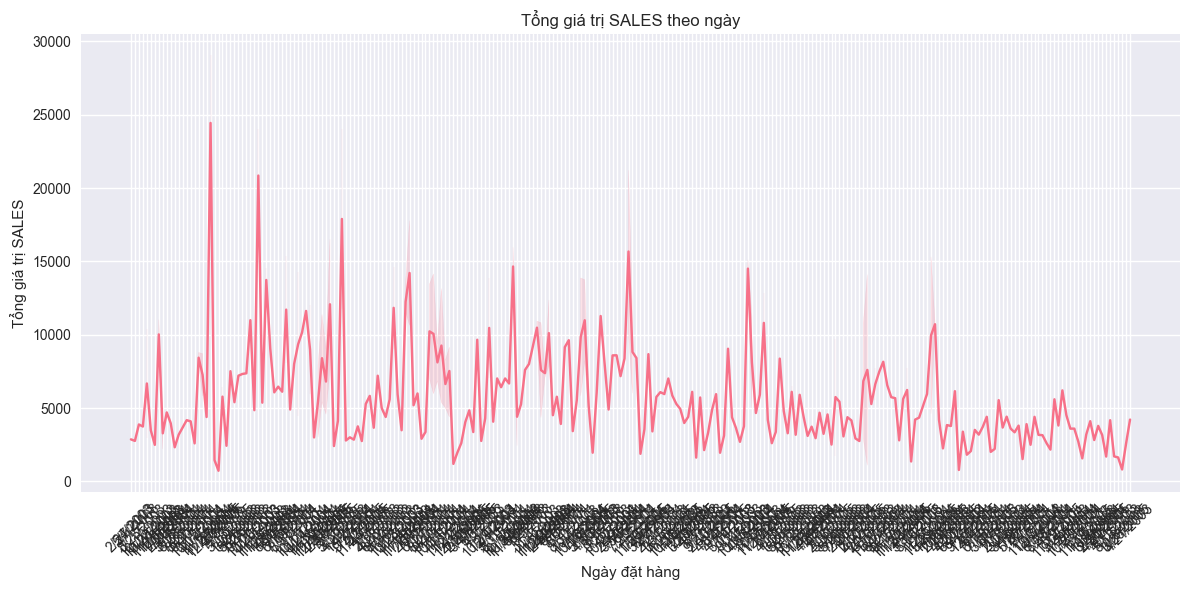

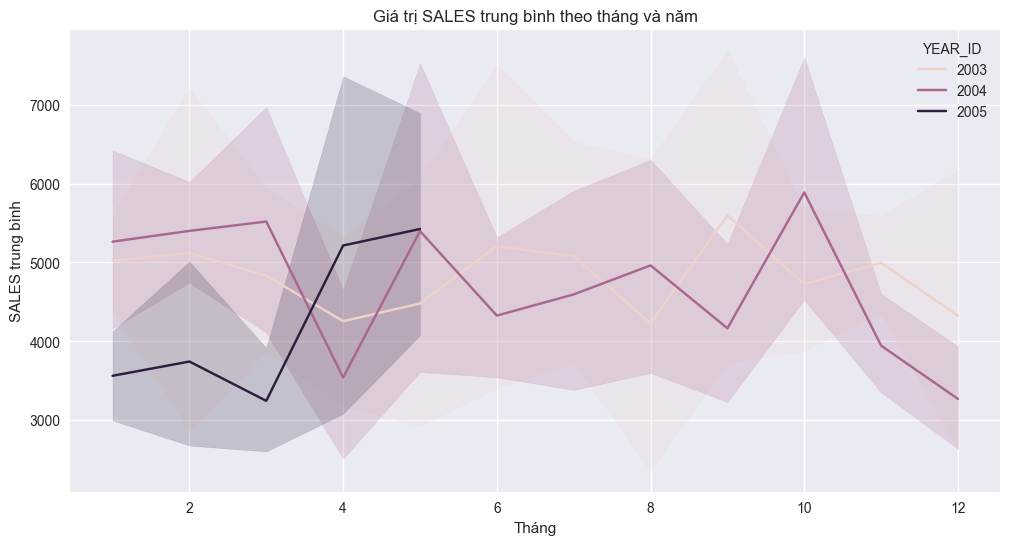

NameError: name 'count_nonzero' is not defined

<Figure size 1200x600 with 0 Axes>

In [48]:
# 2.1.7. Cho biết tổng giá trị SALES theo ngày
plt.figure(figsize=(12, 6))
sns.lineplot(x="ORDERDATE", y="SALES", data=df, estimator=sum)
plt.title('Tổng giá trị SALES theo ngày')
plt.xlabel('Ngày đặt hàng')
plt.ylabel('Tổng giá trị SALES')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2.1.8. Cho biết giá trị SALES trung bình theo tháng năm
plt.figure(figsize=(12, 6))
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID', data=df)
plt.title('Giá trị SALES trung bình theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('SALES trung bình')
plt.show()

# 2.1.8.a Cho biết giá trị SALES theo tháng năm (số lượng)
plt.figure(figsize=(12, 6))
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID', data=df, estimator=count_nonzero)
plt.title('Số lượng đơn hàng theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Số lượng đơn hàng')
plt.show()

# 2.1.9. Cho biết số lượng hóa đơn theo tháng, năm
plt.figure(figsize=(12, 6))
sns.lineplot(x='MONTH_ID', y='ORDERNUMBER', hue='YEAR_ID', data=df, estimator=count_nonzero)
plt.title('Số lượng hóa đơn theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Số lượng hóa đơn')
plt.show()


### 2.3. Biểu đồ cột nhóm (Grouped Bar Plot)


In [ ]:
# 2.1.10. Cho biết giá trị đơn hàng theo trạng thái (STATUS) theo nhóm các năm (YEAR_ID)
plt.figure(figsize=(12, 6))
sns.barplot(x='STATUS', y='SALES', hue='YEAR_ID', data=df, errorbar=None)
plt.title('Giá trị đơn hàng theo STATUS và YEAR_ID')
plt.xlabel('Trạng thái')
plt.ylabel('Giá trị SALES')
plt.show()

# 2.2.1. Cho biết tổng giá trị đơn hàng theo từng trạng thái (STATUS) của mỗi năm
plt.figure(figsize=(12, 6))
sns.barplot(x='STATUS', y='SALES', hue='YEAR_ID', data=df, errorbar=None, estimator=sum)
plt.title('Tổng giá trị đơn hàng theo STATUS và YEAR_ID')
plt.xlabel('Trạng thái')
plt.ylabel('Tổng giá trị SALES')
plt.show()

# 2.2.3. Cho biết số lượng hóa đơn giữa các nhóm DEALSIZE theo từng năm YEAR_ID
plt.figure(figsize=(12, 6))
gb = df.groupby(['DEALSIZE', 'YEAR_ID'])['ORDERNUMBER'].count().unstack()
gb.plot(kind='bar', stacked=True)
plt.title('Số lượng đơn hàng theo DEALSIZE và YEAR_ID')
plt.xlabel('Dealsize')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Năm')
plt.tight_layout()
plt.show()

# 2.2.4. Cho biết trung bình SALES theo từng STATUS và DEALSIZE
plt.figure(figsize=(12, 6))
gb = df.groupby(['STATUS', 'DEALSIZE'])['SALES'].mean().unstack()
gb.plot(kind='barh', stacked=True)
plt.title('Trung bình SALES theo STATUS và DEALSIZE')
plt.xlabel('Trung bình SALES')
plt.ylabel('Trạng thái')
plt.legend(title='Dealsize')
plt.tight_layout()
plt.show()


## 3. Mô tả dữ liệu


In [ ]:
# 3.1. Mô tả dữ liệu cột QuantityOrdered
print("Mô tả dữ liệu cột QUANTITYORDERED:")
print(df['QUANTITYORDERED'].describe())

# 3.2. Mô tả dữ liệu của QUANTITYORDERED, PRICEEACH, SALES
print("\nMô tả dữ liệu của QUANTITYORDERED, PRICEEACH, SALES:")
print(df[['QUANTITYORDERED', 'PRICEEACH', 'SALES']].describe())

# 3.3. Mô tả số lượng bán hàng theo từng DEALSIZE
print("\nMô tả số lượng bán hàng theo từng DEALSIZE:")
print(df.groupby('DEALSIZE')['QUANTITYORDERED'].describe())


## 4. Khai thác sự phân phối dữ liệu (Chỉ dùng trên biến định lượng)


In [ ]:
# 4.1. Vẽ biểu đồ Histogram của QUANTITYORDERED
plt.figure(figsize=(12, 8))

# Histogram cơ bản
plt.subplot(2, 2, 1)
df['QUANTITYORDERED'].hist(bins=20)
plt.title('Histogram QUANTITYORDERED')
plt.xlabel('Số lượng')
plt.ylabel('Tần suất')

# Histogram với KDE
plt.subplot(2, 2, 2)
sns.displot(df, x="QUANTITYORDERED", kind="kde")
plt.title('Phân phối QUANTITYORDERED với KDE')

# 4.2. Vẽ biểu đồ Hist của QUANTITYORDERED theo DEALSIZE
plt.subplot(2, 2, 3)
sns.displot(df, x="QUANTITYORDERED", hue="DEALSIZE", kind="kde")
plt.title('Phân phối QUANTITYORDERED theo DEALSIZE')

# 4.3. Vẽ biểu đồ ECDF
plt.subplot(2, 2, 4)
sns.displot(df, x="QUANTITYORDERED", hue="DEALSIZE", kind="ecdf")
plt.title('ECDF QUANTITYORDERED theo DEALSIZE')

plt.tight_layout()
plt.show()


In [ ]:
# 4.4. Vẽ biểu đồ Histogram theo DEALSIZE
plt.figure(figsize=(10, 6))
sns.displot(df, x="QUANTITYORDERED", hue="DEALSIZE", kind="hist")
plt.title('Histogram QUANTITYORDERED theo DEALSIZE')
plt.show()

# 4.5. Vẽ biểu đồ Jointplot của QUANTITYORDERED và PRICEEACH
plt.figure(figsize=(10, 6))
sns.jointplot(data=df, x='PRICEEACH', y='QUANTITYORDERED', kind='kde', color='y')
plt.suptitle('Jointplot QUANTITYORDERED và PRICEEACH', y=1.02)
plt.show()

# 4.6. Vẽ biểu đồ Pairplot của QUANTITYORDERED, PRICEEACH, SALES
plt.figure(figsize=(12, 8))
sns.pairplot(df[['QUANTITYORDERED', 'PRICEEACH', 'SALES']], diag_kind='hist', kind='kde')
plt.suptitle('Pairplot QUANTITYORDERED, PRICEEACH, SALES', y=1.02)
plt.show()


### 4.2. Biểu đồ Boxplot và Violin Plot


In [ ]:
# 4.8. Vẽ trực quan số lượng sản phẩm phân phối theo năm của QUANTITYORDERED
plt.figure(figsize=(12, 6))
sns.catplot(x='YEAR_ID', y='QUANTITYORDERED', data=df, kind='box')
plt.title('Phân phối QUANTITYORDERED theo năm')
plt.show()

# 4.9. Vẽ trực quan số lượng sản phẩm phân phối theo năm của cột QUANTITYORDERED
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['QUANTITYORDERED'], orient="h")
plt.title('Boxplot QUANTITYORDERED')
plt.show()

# 4.10.1. Biểu thị cho ngoại biên (Boxplot và Violin)
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(12, 6))
sns.boxplot(data=df['QUANTITYORDERED'], ax=axes[0])
sns.violinplot(data=df['QUANTITYORDERED'], ax=axes[1])
axes[0].set_title('Boxplot QUANTITYORDERED')
axes[1].set_title('Violin Plot QUANTITYORDERED')
plt.tight_layout()
plt.show()

# Biểu diễn Boxplot của QUANTITYORDERED theo nhóm DEALSIZE
plt.figure(figsize=(10, 6))
sns.boxplot(x='DEALSIZE', y='QUANTITYORDERED', data=df)
plt.title('Boxplot QUANTITYORDERED theo DEALSIZE')
plt.show()

# Biểu diễn Catplot của QUANTITYORDERED theo nhóm DEALSIZE
plt.figure(figsize=(12, 6))
sns.catplot(x='YEAR_ID', y='QUANTITYORDERED', hue='DEALSIZE', data=df, kind='box')
plt.title('Boxplot QUANTITYORDERED theo năm và DEALSIZE')
plt.show()


In [ ]:
# Biểu diễn Boxplot của QUANTITYORDERED, PRICEEACH
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['QUANTITYORDERED', 'PRICEEACH']])
plt.title('Boxplot QUANTITYORDERED và PRICEEACH')
plt.show()

# Độ xiên của phân phối (Skew) của QUANTITYORDERED, PRICEEACH
print("Độ xiên của phân phối:")
print(df[['QUANTITYORDERED', 'PRICEEACH']].skew())

# Độ nhọn của phân phối (Kurtosis) của QUANTITYORDERED, PRICEEACH
print("\nĐộ nhọn của phân phối:")
print(df[['QUANTITYORDERED', 'PRICEEACH']].kurtosis())

# Kiểm tra tính chuẩn (Normal Distribution) của QUANTITYORDERED
plt.figure(figsize=(10, 6))
stats.probplot(df['QUANTITYORDERED'], plot=plt)
plt.title('Q-Q Plot kiểm tra phân phối chuẩn QUANTITYORDERED')
plt.show()


### 4.3. Chuẩn hóa dữ liệu


In [ ]:
# Tạo bản sao để thực hiện chuẩn hóa
df_normalized = df.copy()

# 4.3.1. Thực hiện Normalize dữ liệu QUANTITYORDERED (Min-Max Scaling)
print("Trước khi chuẩn hóa Min-Max:")
print(f"Min: {df_normalized['QUANTITYORDERED'].min()}, Max: {df_normalized['QUANTITYORDERED'].max()}")

min_max_scaler = preprocessing.MinMaxScaler()
df_normalized[['QUANTITYORDERED']] = min_max_scaler.fit_transform(df_normalized[['QUANTITYORDERED']])

print("Sau khi chuẩn hóa Min-Max:")
print(f"Min: {df_normalized['QUANTITYORDERED'].min()}, Max: {df_normalized['QUANTITYORDERED'].max()}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.displot(df_normalized, x="QUANTITYORDERED", kind="kde")
plt.title('Phân phối sau Min-Max Scaling')

# 4.3.2. Thực hiện Standardization dữ liệu QUANTITYORDERED (Z-score)
df_standardized = df.copy()

print("\nTrước khi chuẩn hóa Z-score:")
print(f"Mean: {df_standardized['QUANTITYORDERED'].mean():.2f}, Std: {df_standardized['QUANTITYORDERED'].std():.2f}")

scaler = StandardScaler()
df_standardized[['QUANTITYORDERED']] = scaler.fit_transform(df_standardized[['QUANTITYORDERED']])

print("Sau khi chuẩn hóa Z-score:")
print(f"Mean: {df_standardized['QUANTITYORDERED'].mean():.2f}, Std: {df_standardized['QUANTITYORDERED'].std():.2f}")

plt.subplot(1, 2, 2)
sns.displot(df_standardized, x="QUANTITYORDERED", kind="kde")
plt.title('Phân phối sau Z-score Standardization')
plt.tight_layout()
plt.show()

# Cách 2: Sử dụng scipy.stats.zscore
df_zscore = df.copy()
df_zscore['QUANTITYORDERED'] = stats.zscore(df_zscore['QUANTITYORDERED'])
print(f"\nSử dụng scipy.stats.zscore - Mean: {df_zscore['QUANTITYORDERED'].mean():.2f}, Std: {df_zscore['QUANTITYORDERED'].std():.2f}")


## 5. Phân tích tương quan


In [ ]:
# 5.1. Ma trận tương quan tuyến tính (Pearson) của các cột QUANTITYORDERED, PRICEEACH, SALES
print("Ma trận tương quan:")
correlation_matrix = df[['QUANTITYORDERED', 'PRICEEACH', 'SALES']].corr()
print(correlation_matrix)

# 5.2. Vẽ biểu đồ Heatmap tương quan giữa các cặp 'QUANTITYORDERED','PRICEEACH','SALES'
plt.figure(figsize=(10, 8))
sns.heatmap(df[['QUANTITYORDERED', 'PRICEEACH', 'SALES']].corr(), 
            vmax=1.0, square=False, annot=True, cmap='coolwarm', center=0)
plt.title('Ma trận tương quan giữa QUANTITYORDERED, PRICEEACH, SALES')
plt.tight_layout()
plt.show()

# 5.3. Tương quan của biến QUANTITYORDERED, PRICEEACH, SALES theo nhóm DEALSIZE
print("\nTương quan theo nhóm DEALSIZE:")
for dealsize in df['DEALSIZE'].unique():
    subset = df[df['DEALSIZE'] == dealsize][['QUANTITYORDERED', 'PRICEEACH', 'SALES']]
    print(f"\n{dealsize}:")
    print(subset.corr())


In [ ]:
# 5.4. Vẽ biểu đồ cho biết giá trị min, max của số lượng sản phẩm trong mỗi đơn hàng theo quý, năm
plt.figure(figsize=(12, 6))
gb = df.groupby(['QTR_ID', 'YEAR_ID'])['QUANTITYORDERED'].agg(['min', 'max'])
gb.plot(kind='bar', stacked=False)
plt.title('Giá trị Min và Max của QUANTITYORDERED theo quý và năm')
plt.xlabel('Quý - Năm')
plt.ylabel('Số lượng')
plt.legend(['Min', 'Max'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5.5. Vẽ biểu đồ cho biết tổng số lượng sản phẩm theo tháng
plt.figure(figsize=(12, 6))
sns.lineplot(x="MONTH_ID", y="QUANTITYORDERED", hue='YEAR_ID', data=df, estimator=sum)
plt.title('Tổng số lượng sản phẩm theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Tổng số lượng')
plt.show()

# 5.6. Vẽ biểu đồ cho biết quan hệ giữa SALES (Oy) và đơn giá (Ox) - Dùng biểu đồ Scatter
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x='PRICEEACH', y='SALES', fit_reg=False)
plt.title('Quan hệ giữa SALES và PRICEEACH')
plt.show()

# 5.7. Vẽ biểu đồ cho biết quan hệ giữa SALES (Oy) và đơn giá (Ox) theo DEALSIZE
plt.figure(figsize=(10, 6))
sns.lmplot(data=df, x='PRICEEACH', y='SALES', hue='DEALSIZE', fit_reg=False)
plt.title('Quan hệ giữa SALES và PRICEEACH theo DEALSIZE')
plt.show()

# 5.8. Vẽ biểu đồ cho biết quan hệ giữa SALES (Oy) và đơn giá (Ox) theo DEALSIZE qua các năm
plt.figure(figsize=(12, 8))
sns.lmplot(data=df, x='PRICEEACH', y='SALES', hue='DEALSIZE', col='YEAR_ID', row='QTR_ID', fit_reg=False)
plt.suptitle('Quan hệ giữa SALES và PRICEEACH theo DEALSIZE, năm và quý', y=1.02)
plt.show()


## 6. Thao tác dữ liệu nâng cao


In [ ]:
# 6.1. Sắp xếp dữ liệu
print("Sắp xếp dữ liệu theo SALES tăng dần:")
print(df.sort_values(by='SALES', ascending=True).head())

print("\nSắp xếp dữ liệu theo nhiều tiêu chí:")
print(df.sort_values(by=['QUANTITYORDERED', 'PRICEEACH'], ascending=[True, False]).head())

# 6.2. Lọc DataFrame
print("\nHiển thị các dòng có Sales > 5000:")
high_sales = df[df['SALES'] > 5000]
print(f"Số dòng có Sales > 5000: {len(high_sales)}")
print(high_sales.head())

print("\nHiển thị các dòng có Sales > 5000 và QuantityOrdered > 40:")
filtered_data = df[(df['SALES'] > 5000) & (df['QUANTITYORDERED'] > 40)]
print(f"Số dòng thỏa mãn cả 2 điều kiện: {len(filtered_data)}")
print(filtered_data.head())


In [ ]:
# 6.3. Tạo cột mới và gán thuộc tính mới trên bảng
# Lọc ra các dòng có Priceeach < 65, nếu có thay giá trị bằng Cheap, ngược lại thay bằng Expensive
df.loc[df['PRICEEACH'] < 65, 'FLAG'] = 'CHEAP'
df.loc[df['PRICEEACH'] >= 65, 'FLAG'] = 'EXPENSIVE'

print("Kết quả sau khi tạo cột FLAG:")
print(df[['PRICEEACH', 'FLAG']].head(10))

# 6.4. Viết hàm và áp dụng
def foo(x):
    if x < 10:
        return 'BAD'
    elif x >= 10 and x < 50:
        return 'GOOD'
    else:
        return 'EXCELLENT'

# Áp dụng cho cột QUANTITYORDERED
df['RATING'] = df[['QUANTITYORDERED']].applymap(foo)

print("\nKết quả sau khi áp dụng hàm foo:")
print(df[['QUANTITYORDERED', 'RATING']].head(10))

# 6.5. So sánh cột
def ftrust(x, y):
    if x <= y:
        return 'YES'
    else:
        return 'NO'

# Áp dụng hàm để gán giá trị trả về cho TRUST
df['TRUST'] = list(map(ftrust, df['PRICEEACH'], df['MSRP']))

print("\nKết quả sau khi so sánh PRICEEACH và MSRP:")
print(df[['PRICEEACH', 'MSRP', 'TRUST']].head(10))


In [ ]:
# 6.6. Ánh xạ giá trị
# Thay đổi giá trị cho cột QTR_ID là Q1 nếu giá trị là 1, Q2 nếu giá trị là 2,...
dict_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['QTR_ID'] = df['QTR_ID'].map(dict_map)

print("Kết quả sau khi ánh xạ QTR_ID:")
print(df['QTR_ID'].value_counts())

# 6.7. Xác định các hàm tổng hợp trên các biến định lượng và định tính
print("\nThống kê tổng hợp:")
aggregated = df.aggregate({
    'QUANTITYORDERED': ['sum', 'min'],
    'PRICEEACH': ['min', 'max', 'mean'],
    'SALES': ['min', 'mean']
})
print(aggregated)

# 6.8. Thống kê tổng, trung vị, độ lệch chuẩn của SALES theo từng nhóm DEALSIZE
print("\nThống kê SALES theo DEALSIZE:")
dealsize_stats = df.groupby(['DEALSIZE'])['SALES'].agg(['sum', 'mean', 'std'])
print(dealsize_stats)

# 6.9. Thống kê tổng, trung vị, độ lệch chuẩn của SALES theo từng nhóm DEALSIZE, cùng DEALSIZE thì nhóm theo QTR_ID
print("\nThống kê SALES theo DEALSIZE và QTR_ID:")
dealsize_qtr_stats = df.groupby(['DEALSIZE', 'QTR_ID'])['SALES'].agg(['sum', 'mean', 'std'])
print(dealsize_qtr_stats)


In [ ]:
# 6.10. Xuất bảng tính theo thuộc tính của bảng (Pivot Table)
print("Bảng Pivot - Thống kê SALES theo YEAR_ID:")
pivot_sales = pd.pivot_table(df, values='SALES', columns='YEAR_ID', aggfunc=['sum', 'mean'])
print(pivot_sales)

print("\nBảng Pivot 2 chiều - Thống kê QUANTITYORDERED và SALES theo YEAR_ID:")
pivot_2d = pd.pivot_table(df, values=['SALES', 'QUANTITYORDERED'], columns='YEAR_ID', aggfunc=['sum', 'mean'])
print(pivot_2d)

# 6.11. Hiển thị thông tin cuối cùng
print(f"\nThông tin cuối cùng về DataFrame:")
print(f"Số dòng: {len(df)}")
print(f"Số cột: {len(df.columns)}")
print(f"Các cột: {list(df.columns)}")

# Lưu dữ liệu cuối cùng
df.to_csv('final_processed_sales_data.csv', sep=',', encoding='utf-8', index=False)
print(f"\nĐã lưu dữ liệu cuối cùng vào file 'final_processed_sales_data.csv'")


In [ ]:
# Sửa lỗi count_nonzero - Sử dụng np.count_nonzero thay vì count_nonzero
print("🔧 Sửa lỗi count_nonzero...")

# 2.1.8.a Cho biết giá trị SALES theo tháng năm (số lượng)
plt.figure(figsize=(12, 6))
sns.lineplot(x="MONTH_ID", y="SALES", hue='YEAR_ID', data=df, estimator=np.count_nonzero)
plt.title('Số lượng đơn hàng theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Số lượng đơn hàng')
plt.show()

# 2.1.9. Cho biết số lượng hóa đơn theo tháng, năm
plt.figure(figsize=(12, 6))
sns.lineplot(x='MONTH_ID', y='ORDERNUMBER', hue='YEAR_ID', data=df, estimator=np.count_nonzero)
plt.title('Số lượng hóa đơn theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Số lượng hóa đơn')
plt.show()

print("✅ Đã sửa lỗi count_nonzero thành công!")
